In [1]:
import polars as pl
import gc # Garbage Collector untuk membersihkan memori

BASE_PATH = "midterm_folder"

# Fungsi optimasi tipe data (Float64 -> Float32)
def optimize_dtypes(lazy_df):
    # Ambil daftar kolom yang bertipe Float64
    float64_cols = [
        col_name for col_name, dtype in lazy_df.schema.items() 
        if dtype == pl.Float64
    ]
    # Ubah menjadi Float32 (hemat RAM 50% per kolom)
    return lazy_df.with_columns([
        pl.col(c).cast(pl.Float32) for c in float64_cols
    ])

print("--- Mulai Loading Data dengan Optimasi RAM ---")

# 1. Gunakan scan_csv (Lazy API) alih-alih read_csv
# Data belum masuk RAM di tahap ini
q_train = pl.scan_csv(f"{BASE_PATH}/train_transaction.csv")
q_test = pl.scan_csv(f"{BASE_PATH}/test_transaction.csv")

# 2. Terapkan Optimasi Tipe Data pada "Rencana" Eksekusi
q_train = optimize_dtypes(q_train)
q_test = optimize_dtypes(q_test)

# 3. Eksekusi (Collect) dengan Mode Streaming
# Streaming memproses data per potongan kecil, sangat hemat RAM
train_transaction = q_train.collect(streaming=True)
test_transaction = q_test.collect(streaming=True)

# Hapus variabel query yang tidak perlu lagi
del q_train, q_test
gc.collect()

print(f"Shape Train: {train_transaction.shape}")
print(f"Shape Test : {test_transaction.shape}")

# Cek estimasi penggunaan memori
mem_train = train_transaction.estimated_size() / (1024**2)
mem_test = test_transaction.estimated_size() / (1024**2)
print(f"Estimasi RAM Train: {mem_train:.2f} MB")
print(f"Estimasi RAM Test : {mem_test:.2f} MB")

--- Mulai Loading Data dengan Optimasi RAM ---


C:\Users\Naufal\AppData\Local\Temp\ipykernel_9820\1601453720.py:10: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  col_name for col_name, dtype in lazy_df.schema.items()
C:\Users\Naufal\AppData\Local\Temp\ipykernel_9820\1601453720.py:31: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  train_transaction = q_train.collect(streaming=True)
C:\Users\Naufal\AppData\Local\Temp\ipykernel_9820\1601453720.py:32: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  test_transaction = q_test.collect(streaming=True)


Shape Train: (590540, 394)
Shape Test : (506691, 393)
Estimasi RAM Train: 900.13 MB
Estimasi RAM Test : 768.72 MB


In [2]:
train_transaction.head() #isFraud adalah target featurenya

TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,…,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
i64,i64,i64,f32,str,i64,f32,f32,str,f32,str,f32,f32,f32,f32,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,…,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
2987000,0,86400,68.5,"""W""",13926,null,150.0,"""discover""",142.0,"""credit""",315.0,87.0,19.0,null,null,null,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,null,13.0,null,null,null,…,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2987001,0,86401,29.0,"""W""",2755,404.0,150.0,"""mastercard""",102.0,"""credit""",325.0,87.0,null,null,"""gmail.com""",null,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,null,null,0.0,null,null,…,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2987002,0,86469,59.0,"""W""",4663,490.0,150.0,"""visa""",166.0,"""debit""",330.0,87.0,287.0,null,"""outlook.com""",null,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,null,null,0.0,null,null,…,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2987003,0,86499,50.0,"""W""",18132,567.0,150.0,"""mastercard""",117.0,"""debit""",476.0,87.0,null,null,"""yahoo.com""",null,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,null,…,0.0,0.0,1.0,50.0,1758.0,925.0,0.0,354.0,0.0,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2987004,0,86506,50.0,"""H""",4497,514.0,150.0,"""mastercard""",102.0,"""credit""",420.0,87.0,null,null,"""gmail.com""",null,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,null,null,null,null,null,…,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# 1. Cek Distribusi Target (Class Imbalance)
# Penting untuk mengetahui seberapa sedikit data fraud
print("--- Distribusi Target (isFraud) ---")
target_counts = train_transaction["isFraud"].value_counts()
print(target_counts)

# Hitung persentase fraud
total_data = train_transaction.height
fraud_count = train_transaction.filter(pl.col("isFraud") == 1).height
print(f"\nPersentase Fraud: {(fraud_count / total_data) * 100:.2f}%")

# 2. Memisahkan Fitur (X) dan Target (y)
# Kita drop 'isFraud' untuk X, dan ambil 'isFraud' saja untuk y
print("\n--- Memisahkan X dan y ---")
y = train_transaction["isFraud"]
X = train_transaction.drop(["isFraud", "TransactionID"]) # Hapus ID juga karena tidak dipakai prediksi

print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")

# Hapus train_transaction besar untuk hemat RAM
# del train_transaction
# gc.collect()

--- Distribusi Target (isFraud) ---
shape: (2, 2)
┌─────────┬────────┐
│ isFraud ┆ count  │
│ ---     ┆ ---    │
│ i64     ┆ u32    │
╞═════════╪════════╡
│ 1       ┆ 20663  │
│ 0       ┆ 569877 │
└─────────┴────────┘

Persentase Fraud: 3.50%

--- Memisahkan X dan y ---
Shape X: (590540, 392)
Shape y: (590540,)


In [4]:
test_transaction.head() #uji data baru, setelah pembuatan model machine learningnya

TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,…,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
i64,i64,f32,str,i64,f32,f32,str,f32,str,f32,f32,f32,f32,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,…,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
3663549,18403224,31.950001,"""W""",10409,111.0,150.0,"""visa""",226.0,"""debit""",170.0,87.0,1.0,null,"""gmail.com""",null,6.0,6.0,0.0,0.0,3.0,4.0,0.0,0.0,6.0,0.0,5.0,1.0,115.0,6.0,419.0,419.0,27.0,398.0,27.0,null,null,…,0.0,0.0,1.0,0.0,47.950001,0.0,0.0,47.950001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
3663550,18403263,49.0,"""W""",4272,111.0,150.0,"""visa""",226.0,"""debit""",299.0,87.0,4.0,null,"""aol.com""",null,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,1.0,12.0,2.0,149.0,149.0,7.0,634.0,7.0,null,null,…,0.0,0.0,1.0,0.0,280.0,77.0,0.0,280.0,0.0,77.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
3663551,18403310,171.0,"""W""",4476,574.0,150.0,"""visa""",226.0,"""debit""",472.0,87.0,2635.0,null,"""hotmail.com""",null,2.0,2.0,0.0,0.0,0.0,5.0,0.0,0.0,4.0,0.0,2.0,0.0,22.0,2.0,137.0,137.0,10.0,97.0,10.0,null,null,…,0.0,0.0,1.0,0.0,1321.0,0.0,0.0,1058.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,263.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
3663552,18403310,284.950012,"""W""",10989,360.0,150.0,"""visa""",166.0,"""debit""",205.0,87.0,17.0,null,"""gmail.com""",null,5.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,2.0,0.0,2.0,0.0,7.0,4.0,42.0,42.0,41.0,242.0,41.0,null,null,…,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,282.540009,282.540009,282.540009,0.0,0.0,0.0,0.0,0.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
3663553,18403317,67.949997,"""W""",18018,452.0,150.0,"""mastercard""",117.0,"""debit""",264.0,87.0,6.0,null,"""gmail.com""",null,6.0,6.0,0.0,0.0,2.0,5.0,0.0,0.0,5.0,0.0,6.0,0.0,14.0,6.0,22.0,22.0,0.0,22.0,0.0,null,null,…,0.0,0.0,1.0,67.949997,183.850006,67.949997,67.949997,183.850006,67.949997,67.949997,67.949997,183.850006,67.949997,0.0,0.0,0.0,0.0,0.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null


In [5]:
print("--- 5 Baris Pertama Data Test ---")
print(test_transaction.head())

# Verifikasi penting: Pastikan tidak ada kolom 'isFraud' (karena ini yang mau kita prediksi)
if "isFraud" not in test_transaction.columns:
    print("\n[OK] Kolom target 'isFraud' TIDAK ADA di data test (Sesuai ekspektasi).")
else:
    print("\n[WARNING] Kolom 'isFraud' ditemukan di data test. Harap cek kembali.")

--- 5 Baris Pertama Data Test ---
shape: (5, 393)
┌───────────────┬───────────────┬────────────────┬───────────┬───┬──────┬──────┬──────┬──────┐
│ TransactionID ┆ TransactionDT ┆ TransactionAmt ┆ ProductCD ┆ … ┆ V336 ┆ V337 ┆ V338 ┆ V339 │
│ ---           ┆ ---           ┆ ---            ┆ ---       ┆   ┆ ---  ┆ ---  ┆ ---  ┆ ---  │
│ i64           ┆ i64           ┆ f32            ┆ str       ┆   ┆ f32  ┆ f32  ┆ f32  ┆ f32  │
╞═══════════════╪═══════════════╪════════════════╪═══════════╪═══╪══════╪══════╪══════╪══════╡
│ 3663549       ┆ 18403224      ┆ 31.950001      ┆ W         ┆ … ┆ null ┆ null ┆ null ┆ null │
│ 3663550       ┆ 18403263      ┆ 49.0           ┆ W         ┆ … ┆ null ┆ null ┆ null ┆ null │
│ 3663551       ┆ 18403310      ┆ 171.0          ┆ W         ┆ … ┆ null ┆ null ┆ null ┆ null │
│ 3663552       ┆ 18403310      ┆ 284.950012     ┆ W         ┆ … ┆ null ┆ null ┆ null ┆ null │
│ 3663553       ┆ 18403317      ┆ 67.949997      ┆ W         ┆ … ┆ null ┆ null ┆ null ┆ null │


In [6]:
import polars as pl
import gc # Garbage Collector

BASE_PATH = "midterm_folder"

# Fungsi untuk mengecilkan ukuran data float (64-bit -> 32-bit)
# Ini menghemat 50% memori untuk setiap kolom angka
def downcast_floats(lazy_df):
    # Cek skema data tanpa load isinya
    schema = lazy_df.schema
    # Ubah semua Float64 menjadi Float32
    return lazy_df.with_columns([
        pl.col(c).cast(pl.Float32) for c, dtype in schema.items() if dtype == pl.Float64
    ])

print("--- Memulai Proses Load Hemat RAM ---")

# 1. Gunakan scan_csv (Lazy Loading)
# Data belum masuk RAM di sini, baru "rencana" saja
q_train = pl.scan_csv(f"{BASE_PATH}/train_transaction.csv")
q_test = pl.scan_csv(f"{BASE_PATH}/test_transaction.csv")

# 2. Terapkan Downcasting pada "Rencana" Eksekusi
q_train = downcast_floats(q_train)
q_test = downcast_floats(q_test)

# 3. Eksekusi (Collect) dengan Mode Streaming
# streaming=True memproses data chunk-by-chunk, sangat ampuh untuk RAM kecil
print("Loading Train Data (Streaming)...")
train_df = q_train.collect(streaming=True)

print("Loading Test Data (Streaming)...")
test_df = q_test.collect(streaming=True)

# Hapus variabel query yang tidak perlu lagi
del q_train, q_test
gc.collect()

# 4. Verifikasi
print("-" * 30)
print(f"Shape train_df: {train_df.shape}")
print(f"Shape test_df : {test_df.shape}")
print("-" * 30)

# Cek penggunaan memori (estimasi)
print(f"Estimasi ukuran Train di RAM: {train_df.estimated_size() / (1024**2):.2f} MB")
train_df.head()

--- Memulai Proses Load Hemat RAM ---
Loading Train Data (Streaming)...


C:\Users\Naufal\AppData\Local\Temp\ipykernel_9820\985204140.py:10: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  schema = lazy_df.schema
C:\Users\Naufal\AppData\Local\Temp\ipykernel_9820\985204140.py:30: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  train_df = q_train.collect(streaming=True)


Loading Test Data (Streaming)...


C:\Users\Naufal\AppData\Local\Temp\ipykernel_9820\985204140.py:33: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  test_df = q_test.collect(streaming=True)


------------------------------
Shape train_df: (590540, 394)
Shape test_df : (506691, 393)
------------------------------
Estimasi ukuran Train di RAM: 900.13 MB


TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,…,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
i64,i64,i64,f32,str,i64,f32,f32,str,f32,str,f32,f32,f32,f32,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,…,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
2987000,0,86400,68.5,"""W""",13926,null,150.0,"""discover""",142.0,"""credit""",315.0,87.0,19.0,null,null,null,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,null,13.0,null,null,null,…,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2987001,0,86401,29.0,"""W""",2755,404.0,150.0,"""mastercard""",102.0,"""credit""",325.0,87.0,null,null,"""gmail.com""",null,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,null,null,0.0,null,null,…,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2987002,0,86469,59.0,"""W""",4663,490.0,150.0,"""visa""",166.0,"""debit""",330.0,87.0,287.0,null,"""outlook.com""",null,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,null,null,0.0,null,null,…,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2987003,0,86499,50.0,"""W""",18132,567.0,150.0,"""mastercard""",117.0,"""debit""",476.0,87.0,null,null,"""yahoo.com""",null,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,null,…,0.0,0.0,1.0,50.0,1758.0,925.0,0.0,354.0,0.0,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2987004,0,86506,50.0,"""H""",4497,514.0,150.0,"""mastercard""",102.0,"""credit""",420.0,87.0,null,null,"""gmail.com""",null,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,null,null,null,null,null,…,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
import polars as pl

def clean_data(df, drop_threshold=0.7):
    print(f"--- Memulai Pengecekan & Pembersihan Data (Shape Awal: {df.shape}) ---")

    # 1. Cek & Hapus Kolom dengan Missing Values Berlebih
    total_rows = df.height
    null_counts = df.null_count()

    # Cari kolom yang null-nya melebihi threshold (misal 70%)
    cols_to_drop = []
    for col in df.columns:
        null_val = null_counts[col][0]
        if (null_val / total_rows) > drop_threshold:
            cols_to_drop.append(col)

    if cols_to_drop:
        print(f"-> Membuang {len(cols_to_drop)} kolom yang > {drop_threshold*100}% kosong.")
        df = df.drop(cols_to_drop)

    # 2. Handling Missing Values (Pengisian Data Kosong)
    cat_cols = df.select(pl.col(pl.Utf8, pl.Categorical)).columns
    num_cols = df.select(pl.col(pl.Float64, pl.Float32, pl.Int64, pl.Int32)).columns

    print("-> Mengisi missing values...")

    # Isi kolom Numerik dengan -999
    fill_num_exprs = [pl.col(c).fill_null(-999) for c in num_cols]
    df = df.with_columns(fill_num_exprs)

    # Isi kolom Kategorikal dengan "Unknown"
    if cat_cols:
        fill_cat_exprs = [pl.col(c).fill_null("Unknown") for c in cat_cols]
        df = df.with_columns(fill_cat_exprs)

    # 3. Cek Duplikat
    n_duplicated = df.is_duplicated().sum()
    if n_duplicated > 0:
        print(f"-> Ditemukan {n_duplicated} baris duplikat. Menghapus...")
        df = df.unique()

    print(f"--- Selesai. Shape Akhir: {df.shape} ---")
    return df

# --- EKSEKUSI ---
print("Membersihkan Train Data...")
train_df_clean = clean_data(train_df)

print("\nMembersihkan Test Data...")
test_df_clean = clean_data(test_df)

# Cek sisa null
sisa_null_train = sum(train_df_clean.null_count().row(0))
print(f"\nSisa Null di Train: {sisa_null_train}")

# --- BAGIAN BARU: MENYIMPAN DATA (SAVING) ---
print("\n--- Menyimpan Data ke File (Parquet) ---")
# Simpan sebagai file .parquet (lebih hemat tempat & cepat dibanding .csv)
train_df_clean.write_parquet("train_clean.parquet")
test_df_clean.write_parquet("test_clean.parquet")

print("Sukses! Data tersimpan sebagai 'train_clean.parquet' dan 'test_clean.parquet'.")

Membersihkan Train Data...
--- Memulai Pengecekan & Pembersihan Data (Shape Awal: (590540, 394)) ---
-> Membuang 168 kolom yang > 70.0% kosong.
-> Mengisi missing values...
--- Selesai. Shape Akhir: (590540, 226) ---

Membersihkan Test Data...
--- Memulai Pengecekan & Pembersihan Data (Shape Awal: (506691, 393)) ---
-> Membuang 168 kolom yang > 70.0% kosong.
-> Mengisi missing values...
--- Selesai. Shape Akhir: (506691, 225) ---

Sisa Null di Train: 0

--- Menyimpan Data ke File (Parquet) ---
Sukses! Data tersimpan sebagai 'train_clean.parquet' dan 'test_clean.parquet'.


In [8]:
# --- TAHAP PREPROCESSING (ENCODING) ---
import gc

print("--- Memulai Encoding Data Kategori ---")

# Gunakan StringCache agar mapping angka konsisten antara Train dan Test
# (Contoh: "Visa" akan jadi angka 5 di kedua dataframe)
with pl.StringCache():
    # 1. Identifikasi kolom yang bertipe String (Utf8)
    # Kita ambil dari train_df_clean yang sudah dibersihkan
    cat_cols = train_df_clean.select(pl.col(pl.Utf8)).columns
    print(f"-> Ditemukan {len(cat_cols)} kolom kategori untuk di-encode.")

    # 2. Fungsi untuk mengubah String -> Categorical -> Integer (Angka Fisik)
    def encode_categorical(df, columns):
        return df.with_columns([
            pl.col(col).cast(pl.Categorical).to_physical()
            for col in columns
        ])

    # 3. Terapkan pada data Train dan Test
    train_final = encode_categorical(train_df_clean, cat_cols)
    test_final = encode_categorical(test_df_clean, cat_cols)

# Hapus variabel lama untuk mengosongkan RAM
del train_df_clean, test_df_clean
gc.collect()

print("-> Encoding selesai.")
print(f"Shape Final Train: {train_final.shape}")
print(f"Shape Final Test : {test_final.shape}")

# --- PERSIAPAN UNTUK MODELING (SPLIT X & y) ---
print("\n--- Memisahkan Fitur (X) dan Target (y) ---")

# Ambil target
y = train_final["isFraud"]

# Buat X (Fitur) dengan membuang Target dan ID
# Kita buang 'TransactionID' karena itu hanya nomor urut, bukan fitur prediktif
X = train_final.drop(["isFraud", "TransactionID"])

# Siapkan data Test (buang TransactionID juga agar kolomnya sama dengan X)
# Simpan ID-nya dulu untuk keperluan submit file nanti
test_ids = test_final["TransactionID"]
X_test_submit = test_final.drop(["TransactionID"])

# Hapus variabel besar terakhir sebelum training
del train_final, test_final
gc.collect()

print("Data siap! Variabel yang tersedia:")
print(f"1. X (Fitur Training) : {X.shape}")
print(f"2. y (Target Training): {y.shape}")
print(f"3. X_test_submit (Untuk Prediksi Nanti): {X_test_submit.shape}")

--- Memulai Encoding Data Kategori ---
-> Ditemukan 13 kolom kategori untuk di-encode.
-> Encoding selesai.
Shape Final Train: (590540, 226)
Shape Final Test : (506691, 225)

--- Memisahkan Fitur (X) dan Target (y) ---
Data siap! Variabel yang tersedia:
1. X (Fitur Training) : (590540, 224)
2. y (Target Training): (590540,)
3. X_test_submit (Untuk Prediksi Nanti): (506691, 224)


Loading data for EDA...
Data Loaded: (590540, 226)
Menghitung korelasi dengan isFraud...


C:\Users\Naufal\AppData\Local\Temp\ipykernel_9820\3984245180.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vals_plot, y=cols_plot, palette="coolwarm")


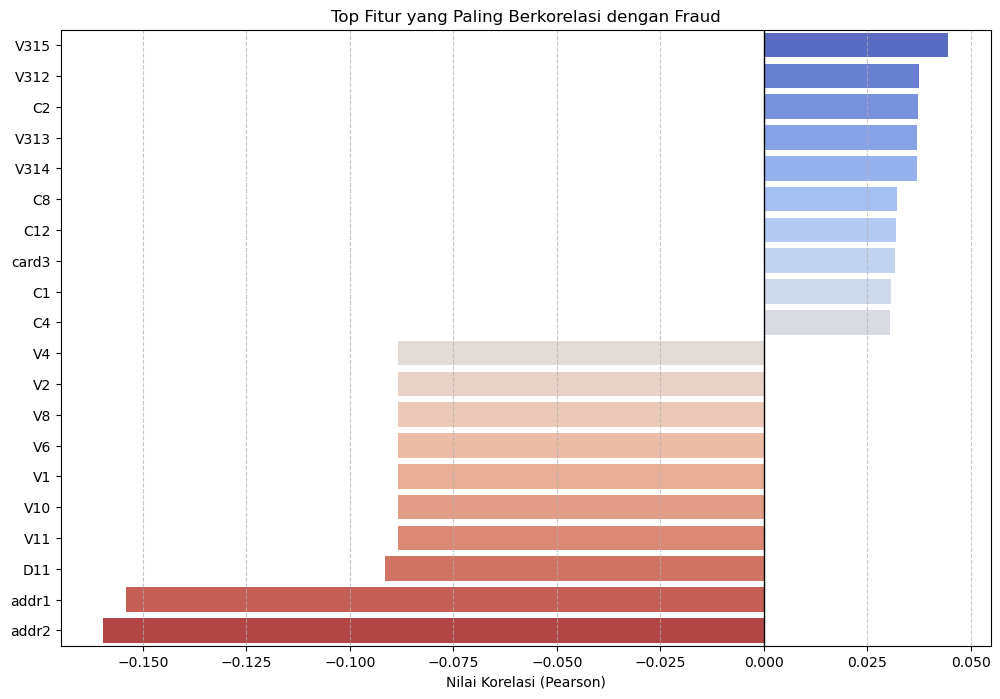


Interpretasi:
Fitur dengan bar ke KANAN (Positif) artinya: Nilai fitur naik, kemungkinan Fraud naik.
Fitur dengan bar ke KIRI (Negatif) artinya: Nilai fitur naik, kemungkinan Fraud turun.


In [9]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import gc

# Load data bersih yang sudah disimpan sebelumnya
# Kita pakai 'read_parquet' karena cepat dan hemat memori
print("Loading data for EDA...")
df = pl.read_parquet("train_clean.parquet")

# Ambil sampel acak jika RAM terbatas (misal 50% data), 
# tapi kalau RAM cukup (12GB+ di Colab), pakai semua tidak masalah.
# df = df.sample(fraction=0.5, seed=42) 

print(f"Data Loaded: {df.shape}")

# --- ANALISIS 1: KORELASI DENGAN TARGET ---
print("Menghitung korelasi dengan isFraud...")

# Kita hitung korelasi setiap kolom numerik terhadap 'isFraud'
correlations = []
target = "isFraud"
features = [c for c in df.columns if c != target and c != "TransactionID"]

# Loop efisien untuk hitung korelasi
# (Polars menghitung corr jauh lebih cepat dari Pandas)
for col in features:
    # Hanya hitung jika kolom numerik
    if df[col].dtype in [pl.Float32, pl.Float64, pl.Int32, pl.Int64]:
        corr_val = df.select(pl.corr(col, target)).item()
        correlations.append((col, corr_val))

# Urutkan dari korelasi positif terkuat ke negatif terkuat
correlations.sort(key=lambda x: x[1], reverse=True)

# Ambil Top 10 Positif dan Top 10 Negatif
top_pos = correlations[:10]
top_neg = correlations[-10:]

# Visualisasi
plt.figure(figsize=(12, 8))
cols_plot = [x[0] for x in top_pos] + [x[0] for x in top_neg]
vals_plot = [x[1] for x in top_pos] + [x[1] for x in top_neg]

sns.barplot(x=vals_plot, y=cols_plot, palette="coolwarm")
plt.title("Top Fitur yang Paling Berkorelasi dengan Fraud")
plt.xlabel("Nilai Korelasi (Pearson)")
plt.axvline(0, color='black', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("\nInterpretasi:")
print("Fitur dengan bar ke KANAN (Positif) artinya: Nilai fitur naik, kemungkinan Fraud naik.")
print("Fitur dengan bar ke KIRI (Negatif) artinya: Nilai fitur naik, kemungkinan Fraud turun.")

Menganalisis TransactionAmt...


c:\Users\Naufal\miniconda3\envs\fraud_detect\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


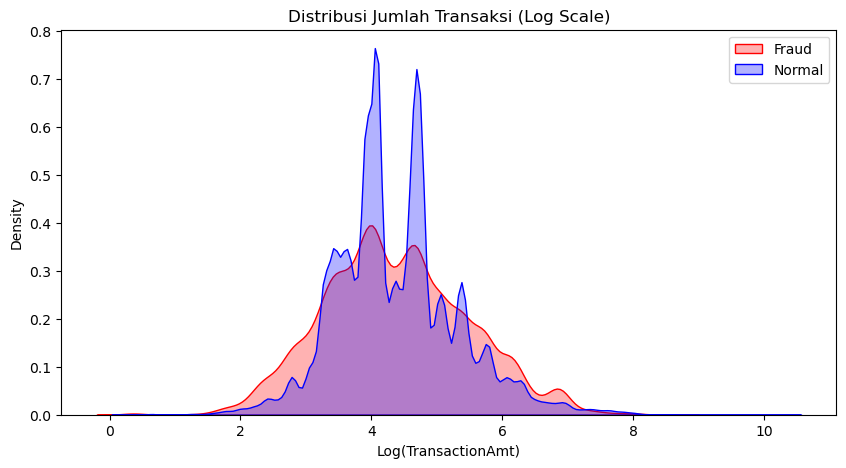

Rata-rata Transaksi Fraud : 149.24
Rata-rata Transaksi Normal: 134.51


In [10]:
# --- ANALISIS 2: DISTRIBUSI TRANSACTION AMOUNT ---
print("Menganalisis TransactionAmt...")

# Ambil data TransactionAmt untuk Fraud (1) dan Normal (0)
# Kita ambil log-nya karena biasanya uang memiliki rentang yang sangat lebar (outlier)
import numpy as np

fraud_amt = df.filter(pl.col("isFraud") == 1)["TransactionAmt"].to_numpy()
normal_amt = df.filter(pl.col("isFraud") == 0)["TransactionAmt"].to_numpy()

plt.figure(figsize=(10, 5))

# Plot Log Distribution
sns.kdeplot(np.log1p(fraud_amt), label='Fraud', fill=True, color='red', alpha=0.3)
sns.kdeplot(np.log1p(normal_amt), label='Normal', fill=True, color='blue', alpha=0.3)

plt.title("Distribusi Jumlah Transaksi (Log Scale)")
plt.xlabel("Log(TransactionAmt)")
plt.ylabel("Density")
plt.legend()
plt.show()

print(f"Rata-rata Transaksi Fraud : {np.mean(fraud_amt):.2f}")
print(f"Rata-rata Transaksi Normal: {np.mean(normal_amt):.2f}")

Memuat ulang data untuk analisis waktu...
Memproses grafik waktu...


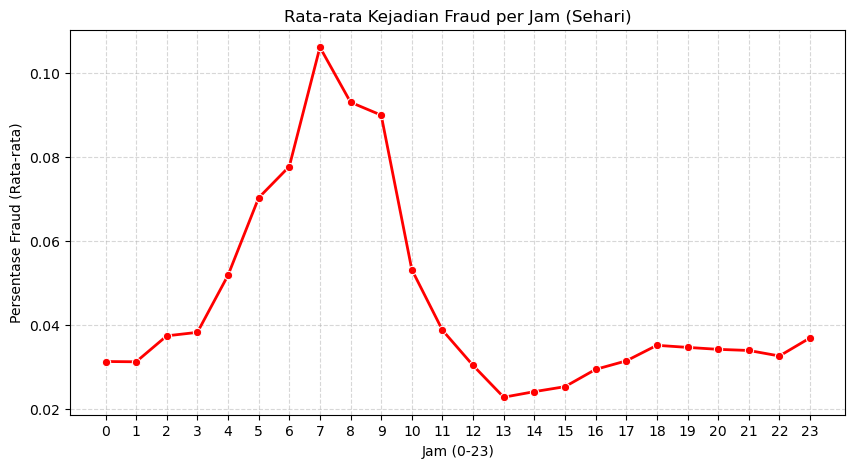

Analisis selesai & memori dibersihkan.


In [11]:
# --- REVISI ANALISIS 3: POLA WAKTU (JAM) ---
import polars as pl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import gc

# 1. LOAD ULANG DATA (Karena df sudah dihapus di cell sebelumnya)
print("Memuat ulang data untuk analisis waktu...")
df = pl.read_parquet("train_clean.parquet")

print("Memproses grafik waktu...")

# 2. PROSES DATA (Dengan pembulatan jam ke Integer agar grafik rapi)
# Menggunakan .cast(pl.Int32) supaya jam jadi angka bulat 0-23
df_time = df.select([
    "isFraud",
    ((pl.col("TransactionDT") / 3600) % 24).cast(pl.Int32).alias("Hour")
])

# 3. AGREGASI (Group By Hour)
fraud_by_hour_pl = df_time.group_by("Hour").agg([
    pl.col("isFraud").mean().alias("Fraud_Rate"),
    pl.len().alias("Count")
]).sort("Hour")

# 4. KONVERSI KE PANDAS UNTUK PLOTTING
fraud_by_hour = pd.DataFrame(fraud_by_hour_pl.to_dict(as_series=False))

# 5. PLOTTING
plt.figure(figsize=(10, 5))
sns.lineplot(data=fraud_by_hour, x="Hour", y="Fraud_Rate", marker="o", color="red", linewidth=2)
plt.title("Rata-rata Kejadian Fraud per Jam (Sehari)")
plt.xlabel("Jam (0-23)")
plt.ylabel("Persentase Fraud (Rata-rata)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(range(0, 24))
plt.show()

# 6. BERSIHKAN MEMORI LAGI
# Kita hapus lagi df agar RAM lega untuk tahap modeling selanjutnya
del df, df_time, fraud_by_hour_pl, fraud_by_hour
gc.collect()
print("Analisis selesai & memori dibersihkan.")

In [12]:
import polars as pl
import gc
import os

# 1. LOAD DATA BERSIH (Dari tahap cleaning sebelumnya)
print("--- Memuat Data Bersih untuk Feature Engineering ---")
if os.path.exists("train_clean.parquet") and os.path.exists("test_clean.parquet"):
    train = pl.read_parquet("train_clean.parquet")
    test = pl.read_parquet("test_clean.parquet")
    print(f"Data Loaded. Train: {train.shape}, Test: {test.shape}")
else:
    raise FileNotFoundError("File .parquet tidak ditemukan. Jalankan cell Cleaning & Saving dulu!")

# 2. DEFINISI FUNGSI FEATURE ENGINEERING
def feature_engineering(df):
    print(f"Engineering features for shape: {df.shape}...")
    
    # A. TIME FEATURES
    # Mengekstrak Jam dan Hari dari TransactionDT
    df = df.with_columns([
        ((pl.col("TransactionDT") / 3600) % 24).cast(pl.Int32).alias("hour"),
        ((pl.col("TransactionDT") / (3600 * 24)) % 7).cast(pl.Int32).alias("day_of_week"),
    ])
    
    # B. DECIMAL PART OF TRANSACTION AMOUNT
    # Penipu sering pakai angka bulat atau angka aneh (misal 99.99 vs 100.00)
    df = df.with_columns([
        (pl.col("TransactionAmt") - pl.col("TransactionAmt").floor()).alias("decimal_part")
    ])
    
    # C. AGGREGATION FEATURES (Statistik per Kelompok)
    # Menghitung rata-rata transaksi per kartu (card1)
    # Apakah transaksi ini mencurigakan dibanding history kartu tersebut?
    df = df.with_columns([
        pl.col("TransactionAmt").mean().over("card1").alias("card1_amt_mean"),
        pl.col("TransactionAmt").std().over("card1").alias("card1_amt_std")
    ])
    
    # Normalisasi Amount terhadap rata-rata kelompoknya
    df = df.with_columns([
        (pl.col("TransactionAmt") - pl.col("card1_amt_mean")).alias("TransactionAmt_diff_mean")
    ])
    
    # D. INTERACTION / COMBINED FEATURES (Membuat User ID Unik)
    # Menggabungkan card1 + addr1 + P_emaildomain sebagai string untuk identitas unik
    # Kita cast ke string dulu sebelum concat
    df = df.with_columns([
        (pl.col("card1").cast(pl.Utf8) + "_" + 
         pl.col("addr1").cast(pl.Utf8) + "_" + 
         pl.col("P_emaildomain").fill_null("unknown")).alias("uid_1")
    ])
    
    return df

# 3. TERAPKAN KE TRAIN DAN TEST
print("-> Menerapkan Feature Engineering...")
train = feature_engineering(train)
test = feature_engineering(test)

# 4. ENCODING ULANG (Termasuk fitur baru)
print("\n--- Melakukan Encoding Final ---")

# Gabungkan data sementara untuk memastikan encoding konsisten
# (Kita pakai StringCache seperti sebelumnya tapi kali ini kita explicit kan kolom kategorinya)
with pl.StringCache():
    # Identifikasi semua kolom string (termasuk uid_1 yang baru dibuat)
    cat_cols = train.select(pl.col(pl.Utf8, pl.Categorical)).columns
    print(f"-> Kolom kategori yang akan di-encode: {len(cat_cols)}")
    
    # Fungsi encode
    def encode_final(df, columns):
        return df.with_columns([
            pl.col(col).cast(pl.Categorical).to_physical() 
            for col in columns
        ])
    
    train_final = encode_final(train, cat_cols)
    test_final = encode_final(test, cat_cols)

# Hapus variabel raw untuk hemat RAM
del train, test
gc.collect()

print("Feature Engineering Selesai!")
print(f"Shape Final Train: {train_final.shape}")
print(f"Shape Final Test : {test_final.shape}")

# 5. PERSIAPAN FINAL X DAN y
print("\n--- Memisahkan X dan y ---")
y = train_final["isFraud"]
X = train_final.drop(["isFraud", "TransactionID"])

# Simpan ID test untuk submission
test_ids = test_final["TransactionID"]
X_test_submit = test_final.drop(["TransactionID"])

print("Data siap masuk ke Modeling!")

--- Memuat Data Bersih untuk Feature Engineering ---
Data Loaded. Train: (590540, 226), Test: (506691, 225)
-> Menerapkan Feature Engineering...
Engineering features for shape: (590540, 226)...
Engineering features for shape: (506691, 225)...

--- Melakukan Encoding Final ---
-> Kolom kategori yang akan di-encode: 14
Feature Engineering Selesai!
Shape Final Train: (590540, 233)
Shape Final Test : (506691, 232)

--- Memisahkan X dan y ---
Data siap masuk ke Modeling!


In [15]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.model_selection import train_test_split

print("--- Memulai Training Model XGBoost (Versi Baru) ---")

# 1. Load Data X dan y (jika belum ada di memori)
# Pastikan X dan y sudah tersedia dari tahap preprocessing sebelumnya
# Jika hilang, jalankan ulang cell preprocessing/encoding.

# 2. Split Data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Hitung Scale Pos Weight
ratio = float(len(y_train) - sum(y_train)) / sum(y_train)
print(f"Ratio Scale Pos Weight: {ratio:.2f}")

# 4. Konfigurasi Model (PERUBAHAN ADA DI SINI)
# eval_metric dan early_stopping_rounds kita pindahkan ke dalam kurung ini
clf = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
    scale_pos_weight=ratio,
    device="cpu",          # Gunakan "cuda" jika ada GPU
    # --- PARAMETER BARU PINDAH KE SINI ---
    eval_metric='auc',     
    early_stopping_rounds=30 
)

# 5. Training
print("Sedang melatih model... (Bisa memakan waktu 2-5 menit)")

# Di sini kita HAPUS parameter yang tadi error, sisa eval_set dan verbose saja
clf.fit(X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=50) 

# 6. Evaluasi Akhir
print("\n--- Hasil Evaluasi ---")
y_pred_proba = clf.predict_proba(X_val)[:, 1]
print(f"ROC-AUC Score: {roc_auc_score(y_val, y_pred_proba):.4f}")
print("\nClassification Report:")
y_pred = clf.predict(X_val)
print(classification_report(y_val, y_pred))

--- Memulai Training Model XGBoost (Versi Baru) ---
Ratio Scale Pos Weight: 27.58
Sedang melatih model... (Bisa memakan waktu 2-5 menit)
[0]	validation_0-auc:0.86127
[50]	validation_0-auc:0.93548
[100]	validation_0-auc:0.95033
[150]	validation_0-auc:0.95768
[200]	validation_0-auc:0.96128
[250]	validation_0-auc:0.96376
[300]	validation_0-auc:0.96520
[350]	validation_0-auc:0.96642
[400]	validation_0-auc:0.96740
[450]	validation_0-auc:0.96817
[499]	validation_0-auc:0.96851

--- Hasil Evaluasi ---
ROC-AUC Score: 0.9685

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99    113975
           1       0.64      0.80      0.71      4133

    accuracy                           0.98    118108
   macro avg       0.82      0.89      0.85    118108
weighted avg       0.98      0.98      0.98    118108



In [18]:
import lightgbm as lgb
import time
import numpy as np # Import numpy
from sklearn.metrics import roc_auc_score

print("--- Memulai Training LightGBM (Fix Version) ---")
start_time = time.time()

# 1. Konfigurasi LightGBM
lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=ratio,
    verbose=-1
)

# 2. Training dengan .to_numpy()
# KITAU UBAH DI SINI: Tambahkan .to_numpy() agar inputnya berupa array polos
# Ini mencegah error "feature_names_in_"
print("Sedang melatih model LightGBM...")

lgbm.fit(X_train.to_numpy(), y_train.to_numpy(),
         eval_set=[(X_val.to_numpy(), y_val.to_numpy())],
         eval_metric='auc')

lgbm_time = time.time() - start_time
print(f"-> Training Selesai dalam {lgbm_time:.2f} detik.")

# 3. Hitung Skor Akhir
# Saat prediksi juga harus pakai .to_numpy() agar formatnya sama
y_pred_lgbm = lgbm.predict_proba(X_val.to_numpy())[:, 1]
lgbm_auc = roc_auc_score(y_val, y_pred_lgbm)

print(f"-> LightGBM ROC-AUC Score: {lgbm_auc:.4f}")

--- Memulai Training LightGBM (Fix Version) ---
Sedang melatih model LightGBM...
-> Training Selesai dalam 25.90 detik.


c:\Users\Naufal\miniconda3\envs\fraud_detect\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


-> LightGBM ROC-AUC Score: 0.9491


--- PERBANDINGAN HASIL MODEL: XGBoost vs LightGBM ---
Mengambil prediksi dari XGBoost...

[ TABEL SKOR AKHIR ]
      Model  ROC-AUC Score Kesimpulan
0   XGBoost       0.968508     Winner
1  LightGBM       0.949084  Runner Up


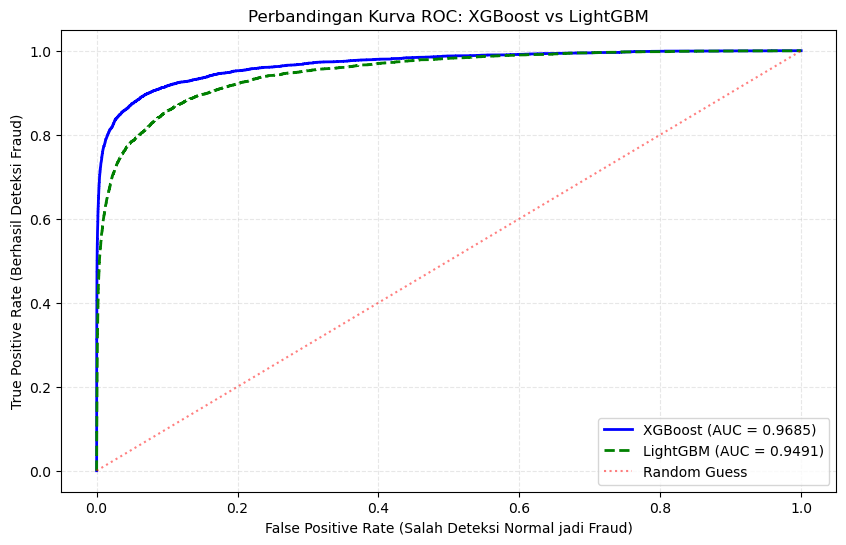


Korelasi Prediksi antar Model: 0.7996
-> Kedua model memiliki cara pandang yang agak berbeda (bisa di-ensemble).


In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_curve

print("--- PERBANDINGAN HASIL MODEL: XGBoost vs LightGBM ---")

# 1. Cek Ketersediaan Model XGBoost
if 'clf' not in locals():
    print("⚠️ WARNING: Model XGBoost (clf) tidak ditemukan di memori!")
    print("Harap jalankan cell training XGBoost terlebih dahulu agar bisa dibandingkan.")
else:
    # 2. Ambil Prediksi XGBoost (Recalculate biar aman)
    print("Mengambil prediksi dari XGBoost...")
    y_pred_xgb = clf.predict_proba(X_val)[:, 1]
    xgb_auc = roc_auc_score(y_val, y_pred_xgb)

    # 3. Tabel Perbandingan Skor
    print("\n[ TABEL SKOR AKHIR ]")
    results = pd.DataFrame({
        'Model': ['XGBoost', 'LightGBM'],
        'ROC-AUC Score': [xgb_auc, lgbm_auc],
        'Kesimpulan': ['-' if xgb_auc == lgbm_auc else ('Winner' if xgb_auc > lgbm_auc else 'Runner Up'),
                       '-' if xgb_auc == lgbm_auc else ('Winner' if lgbm_auc > xgb_auc else 'Runner Up')]
    })
    print(results)

    # 4. Visualisasi Kurva ROC (Siapa yang kurvanya lebih tinggi?)
    fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_pred_xgb)
    fpr_lgb, tpr_lgb, _ = roc_curve(y_val, y_pred_lgbm)

    plt.figure(figsize=(10, 6))
    
    # Plot XGBoost
    plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {xgb_auc:.4f})', color='blue', linewidth=2)
    
    # Plot LightGBM
    plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {lgbm_auc:.4f})', color='green', linestyle='--', linewidth=2)
    
    # Garis Random (Jika model menebak ngawur)
    plt.plot([0, 1], [0, 1], 'r:', label='Random Guess', alpha=0.5)

    plt.title('Perbandingan Kurva ROC: XGBoost vs LightGBM')
    plt.xlabel('False Positive Rate (Salah Deteksi Normal jadi Fraud)')
    plt.ylabel('True Positive Rate (Berhasil Deteksi Fraud)')
    plt.legend(loc="lower right")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

    # 5. Analisis Korelasi Prediksi
    # Apakah kedua model "sepakat" dalam menebak fraud?
    # Jika korelasi tinggi (>0.95), berarti kedua model belajar pola yang sama.
    correlation = pd.Series(y_pred_xgb).corr(pd.Series(y_pred_lgbm))
    print(f"\nKorelasi Prediksi antar Model: {correlation:.4f}")
    if correlation > 0.95:
        print("-> Kedua model sangat mirip dalam memprediksi data.")
    else:
        print("-> Kedua model memiliki cara pandang yang agak berbeda (bisa di-ensemble).")

In [21]:
import polars as pl
import pandas as pd
import os

print("--- MENAMPILKAN TOP 30 TRANSAKSI SUSPECT FRAUD (AUTO-FIX) ---")

# 1. Cek atau Buat Ulang Variabel Submission
if 'submission' not in locals():
    print("Variabel 'submission' tidak ditemukan di memori.")
    
    # Coba baca dari file
    if os.path.exists('submission_xgboost.csv'):
        print("-> Membaca dari file CSV...")
        submission = pd.read_csv('submission_xgboost.csv')
    
    # Jika file tidak ada, KITA BUAT ULANG SEKARANG (Asal Model ada)
    elif 'clf' in locals() and 'X_test_submit' in locals():
        print("-> File CSV tidak ada. Membuat prediksi ulang langsung dari Model...")
        # Prediksi ulang
        y_test_pred = clf.predict_proba(X_test_submit)[:, 1]
        submission = pd.DataFrame({
            'TransactionID': test_ids, # Pastikan test_ids ada (dari cell Feature Engineering)
            'isFraud': y_test_pred
        })
    else:
        # Jika Model pun tidak ada, angkat tangan
        raise ValueError("""
        CRITICAL ERROR: Tidak bisa membuat Top 30.
        Penyebab: Model (clf) atau Data Test (X_test_submit) hilang dari memori.
        SOLUSI: Harap jalankan ulang cell 'Training XGBoost' dan 'Feature Engineering' di atas!
        """)

# 2. Ambil 30 TransactionID dengan Probability Tertinggi
top_30_fraud = submission.sort_values(by="isFraud", ascending=False).head(30)
top_30_ids = top_30_fraud["TransactionID"].tolist()

print(f"Mengambil detail data untuk {len(top_30_ids)} transaksi paling mencurigakan...")

# 3. Ambil Detail Asli dari File Parquet (Data Readable)
# Pastikan file parquet ada. Jika tidak, pakai X_test_submit sementara
if os.path.exists("test_clean.parquet"):
    top_30_details = (
        pl.scan_parquet("test_clean.parquet")
        .filter(pl.col("TransactionID").is_in(top_30_ids))
        .collect()
    )
    df_display = top_30_details.to_pandas()
else:
    print("WARNING: test_clean.parquet tidak ditemukan. Menampilkan data ID dan Score saja.")
    df_display = top_30_fraud.copy()

# 4. Gabungkan Score ke dalam Data Detail
# Map TransactionID ke skor isFraud
id_to_prob = dict(zip(top_30_fraud["TransactionID"], top_30_fraud["isFraud"]))

# Jika df_display punya TransactionID (dari parquet), kita map.
if "TransactionID" in df_display.columns:
    df_display["Fraud_Probability"] = df_display["TransactionID"].map(id_to_prob)
    df_display = df_display.sort_values(by="Fraud_Probability", ascending=False)
    
    # Rapikan urutan kolom
    cols = ["TransactionID", "Fraud_Probability"] + [c for c in df_display.columns if c not in ["TransactionID", "Fraud_Probability"]]
    df_display = df_display[cols]

# 5. Tampilkan Hasil
print("\n[ TOP 30 TRANSAKSI FRAUD PREDICTION ]")
# Pilih kolom penting untuk ditampilkan (jika ada di data)
target_cols = ['TransactionID', 'Fraud_Probability', 'TransactionAmt', 'ProductCD', 'card4', 'card6', 'P_emaildomain', 'addr1', 'addr2', 'dist1']
available_cols = [c for c in target_cols if c in df_display.columns]

# Tampilkan tabel
print(df_display[available_cols].to_string(index=False))

--- MENAMPILKAN TOP 30 TRANSAKSI SUSPECT FRAUD (AUTO-FIX) ---
Variabel 'submission' tidak ditemukan di memori.
-> File CSV tidak ada. Membuat prediksi ulang langsung dari Model...
Mengambil detail data untuk 30 transaksi paling mencurigakan...

[ TOP 30 TRANSAKSI FRAUD PREDICTION ]
 TransactionID  Fraud_Probability  TransactionAmt ProductCD      card4  card6 P_emaildomain  addr1  addr2  dist1
       3873929           0.999709       25.207001         C       visa credit   hotmail.com -999.0 -999.0 -999.0
       3952699           0.999656       23.239000         C mastercard credit   hotmail.com -999.0 -999.0 -999.0
       3759538           0.999627       28.096001         C       visa  debit     gmail.com -999.0 -999.0 -999.0
       3843549           0.999582       14.386000         C mastercard credit   hotmail.com -999.0 -999.0 -999.0
       3698416           0.999532       80.169998         C mastercard credit   hotmail.com -999.0 -999.0 -999.0
       3966204           0.999495      